## 1. Introduction: The Global Raster Strategy

In Notebook 1, we established a set of 'Spatial Anchors'—specific building coordinates where we want to sample our data. In this notebook, we generate the ground-truth masks for our segmentation model (Built-Up Area).

**The Strategy:**
Instead of performing expensive vector-to-raster calculations for every single building crop (which is slow and redundant), we will:
1. **Rasterize the entire City of Zürich** Biotope map into one massive high-resolution grid.
2. **Save this Global Mask** to disk as a GeoTIFF. 
3. **Treat the Global Mask as a Database:** When we need a mask for a specific building, we simply 'slice' the required pixels out of the big file.

This approach is significantly faster when scaling to thousands of images and ensures that if we change our building samples later, we don't have to re-process the complex biotope geometry.

In [10]:
import os
import math
import numpy as np
import geopandas as gpd
import rasterio
from rasterio import features
from rasterio.windows import from_bounds
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# --- Directory Configuration ---
BASE_OUT = "../data/processed_modular"
META_DIR = f"{BASE_OUT}/metadata"
MASK_TASK_NAME = "masks_builtup"
GLOBAL_MASK_PATH = f"{META_DIR}/global_builtup_mask_2056.tif"
ANCHOR_PATH = f"{META_DIR}/building_anchors_2000.gpkg"
BIOTOPE_PATH = "/Users/fadricampell/Documents/HSLU/Modules/rBootcamp/r-bootcamp/data/biotoptypen2020/data/gsz.btk_2020.shp"


# --- Hyperparameters ---
# These must match Notebook 1 exactly to ensure spatial alignment
CROP_RADIUS_M = 50 
IMG_SIZE = 512
TARGET_RES = 100 / 512.0  # Approx 0.195m per pixel

## 2. Preparing the Biotope Vector Data

We load the official Biotope Mapping (BTK 2020) provided by the City of Zürich. Our goal for this task is **Binary Segmentation**: identifying "Built-up" (sealed/urban) areas versus everything else.

According to the data dictionary:
* **Class 13** (`lrtyp1code`) represents built-up areas and buildings.
* We map this to a value of **1**.
* All other classes (forests, meadows, water) are mapped to **0**.

In [11]:
print("Loading biotope vectors...")
gdf = gpd.read_file(BIOTOPE_PATH)

# Ensure CRS is Swiss LV95 (Metric)
if gdf.crs.to_string() != 'EPSG:2056':
    gdf = gdf.to_crs(epsg=2056)

# Binary Labeling: 1 for Built-up, 0 for everything else
gdf['builtup_mask_val'] = gdf['lrtyp1code'].apply(lambda x: 1 if str(x) == "13" else 0)

print(f"Features loaded: {len(gdf)}")

Loading biotope vectors...
Features loaded: 96178


## 3. Creating the Global Master Mask

Now we 'burn' the polygons into a raster grid. We calculate the total bounding box of the entire city and determine the necessary pixel dimensions based on our target resolution (~0.19m). 

The result is saved as a compressed GeoTIFF. This file acts as our permanent spatial reference. 
*Note: We use `uint8` to keep file size small while supporting class indices.*

In [12]:
if not os.path.exists(GLOBAL_MASK_PATH):
    print("Generating Global Raster (this may take a minute)...")
    
    # Calculate global grid dimensions
    minx, miny, maxx, maxy = gdf.total_bounds
    width = math.ceil((maxx - minx) / TARGET_RES)
    height = math.ceil((maxy - miny) / TARGET_RES)
    
    # Define the affine transform (Origin and pixel size)
    global_transform = rasterio.transform.from_origin(minx, maxy, TARGET_RES, TARGET_RES)
    
    # Use GDAL's optimized rasterize function
    global_mask_array = features.rasterize(
        shapes=((geom, val) for geom, val in zip(gdf.geometry, gdf['builtup_mask_val'])),
        out_shape=(height, width),
        transform=global_transform,
        fill=0,
        dtype=rasterio.uint8
    )
    
    # Save the master file
    with rasterio.open(
        GLOBAL_MASK_PATH, 'w',
        driver='GTiff', height=height, width=width, count=1, 
        dtype=rasterio.uint8, crs='EPSG:2056', transform=global_transform, compress='lzw'
    ) as ds:
        ds.write(global_mask_array, 1)
    print(f"✅ Global mask created: {width}x{height} pixels.")
else:
    print(f"✅ Reusing existing global mask: {GLOBAL_MASK_PATH}")

✅ Reusing existing global mask: ../data/processed_modular/metadata/global_builtup_mask_2056.tif


## 4. Extracting Localized Patches

With the Global Mask ready, we loop through our building anchors. For each building, we calculate the 'Window' (the pixel coordinates) within the big file and read only that small 512x512 patch.

This is nearly instantaneous because we are using **Windowed Reading**, which avoids loading the entire city into memory for every single building.

In [13]:
# Load the anchors from Notebook 1
gdf_anchors = gpd.read_file(ANCHOR_PATH)

# Open the global mask for reading
with rasterio.open(GLOBAL_MASK_PATH) as src_global:
    
    for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
        uid = row['unique_id']
        split = row['split']
        out_folder = f"{BASE_OUT}/{split}/{MASK_TASK_NAME}"
        os.makedirs(out_folder, exist_ok=True)
        
        out_path = f"{out_folder}/{uid}_mask.tif"
        if os.path.exists(out_path): continue
        
        # Calculate the bounding box for this specific building
        win_minx, win_maxx = row['x_2056'] - CROP_RADIUS_M, row['x_2056'] + CROP_RADIUS_M
        win_miny, win_maxy = row['y_2056'] - CROP_RADIUS_M, row['y_2056'] + CROP_RADIUS_M
        
        # Determine the window (pixel coords) in the global file
        window = from_bounds(win_minx, win_miny, win_maxx, win_maxy, src_global.transform)
        
        # Read patch (boundless=True pads with 0 if we hit the edge of the city)
        mask_patch = src_global.read(1, window=window, boundless=True, fill_value=0, out_shape=(IMG_SIZE, IMG_SIZE))
        
        # Update metadata for the small patch
        patch_meta = src_global.meta.copy()
        patch_meta.update({
            "height": IMG_SIZE, "width": IMG_SIZE,
            "transform": rasterio.windows.transform(window, src_global.transform)
        })
        
        with rasterio.open(out_path, 'w', **patch_meta) as dest:
            dest.write(mask_patch, 1)

print("✅ Mask extraction complete.")

  0%|          | 0/2000 [00:00<?, ?it/s]

✅ Mask extraction complete.


## 5. Sanity Check: Mask Alignment

Finally, we overlay a random image and its new mask. Even if the mask looks "black" in a standard file viewer (due to 0/1 values), this plot will confirm if the spatial alignment is pixel-perfect.

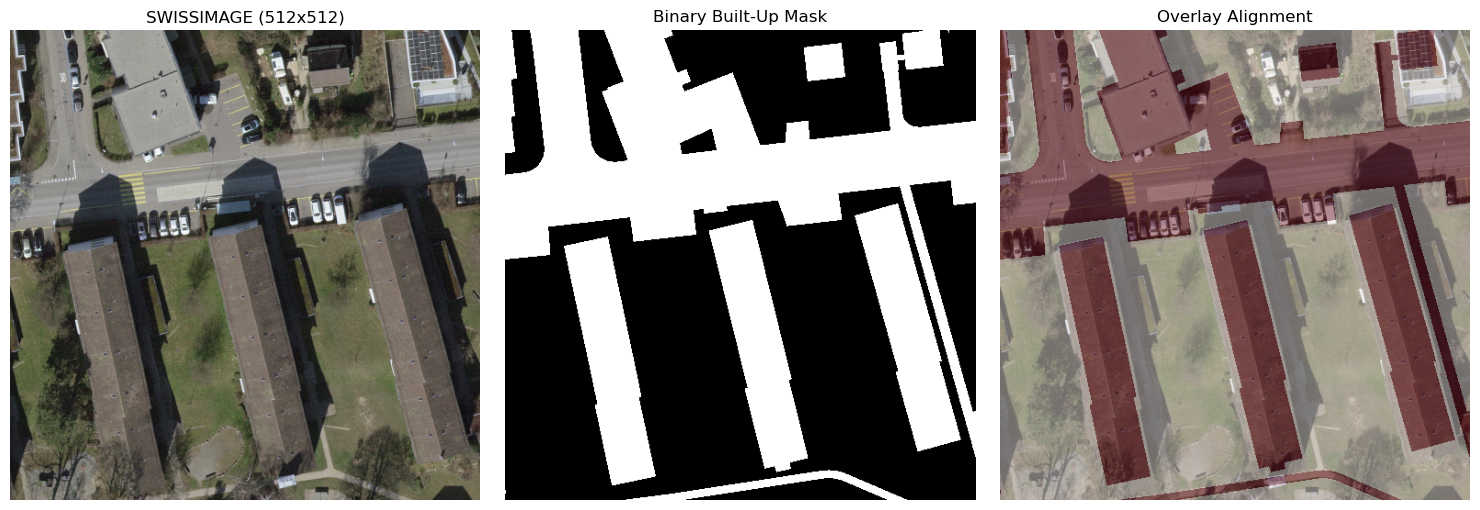

In [16]:
# Grab a random anchor from the training set
sample_row = gdf_anchors[gdf_anchors['split'] == 'train'].sample().iloc[0]
uid = sample_row['unique_id']

img_path = f"{BASE_OUT}/train/images/{uid}_swissimage.tif"
mask_path = f"{BASE_OUT}/train/{MASK_TASK_NAME}/{uid}_mask.tif"

if os.path.exists(img_path) and os.path.exists(mask_path):
    with rasterio.open(img_path) as src_img:
        # Swisstopo might return 3 (RGB) or 4 (RGBA) channels
        img = src_img.read()[:3] 
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = np.moveaxis(img, 0, -1) 
        
    with rasterio.open(mask_path) as src_mask:
        mask = src_mask.read(1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img)
    axs[0].set_title("SWISSIMAGE (512x512)")
    axs[0].axis("off")
    
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Binary Built-Up Mask")
    axs[1].axis("off")
    
    # Overlay
    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="Reds", alpha=0.4) # Overlay mask in semi-transparent red
    axs[2].set_title("Overlay Alignment")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find both files for UID: {uid}. Ensure Notebook 1 ran successfully.")